In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Mon Sep 15 10:13:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!git clone https://github.com/WongKinYiu/yolov9.git
%cd yolov9
!pip install -r requirements.txt -q

Cloning into 'yolov9'...
remote: Enumerating objects: 781, done.
remote: Counting objects: 100% (316/316), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 781 (delta 265), reused 257 (delta 257), pack-reused 465 (from 1)
Receiving objects: 100% (781/781), 3.25 MiB | 24.12 MiB/s, done.
Resolving deltas: 100% (339/339), done.
/content/yolov9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s eta 0:00:00


In [ ]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.9 MB/s eta 0:00:00


## Download model weights

**NOTE:** In the YOLOv9 paper, versions `yolov9-s` and `yolov9-m` are also mentioned, but the weights for these models are not yet available in the YOLOv9 [repository](https://github.com/WongKinYiu/yolov9).

In [ ]:

!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-s-converted.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt

In [ ]:

!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-s.pt

Added weights_only = False parameter to the experimental.py file in yolov9 (yolov9 > models > experimental.py)

 ckpt = torch.load(attempt_download(w), map_location='cpu', weights_only=False)

 line 243

In [ ]:
!python detect.py --weights {HOME}/weights/gelan-s.pt --source "/content/test_yolo.png" --device 0

detect: weights=['/content/weights/gelan-s.pt'], source=/content/test_yolo.png, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 489 layers, 7105888 parameters, 0 gradients, 26.4 GFLOPs
image 1/1 /content/test_yolo.png: 384x640 3 persons, 13 cars, 56.2ms
Speed: 0.4ms pre-process, 56.2ms inference, 102.1ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp3


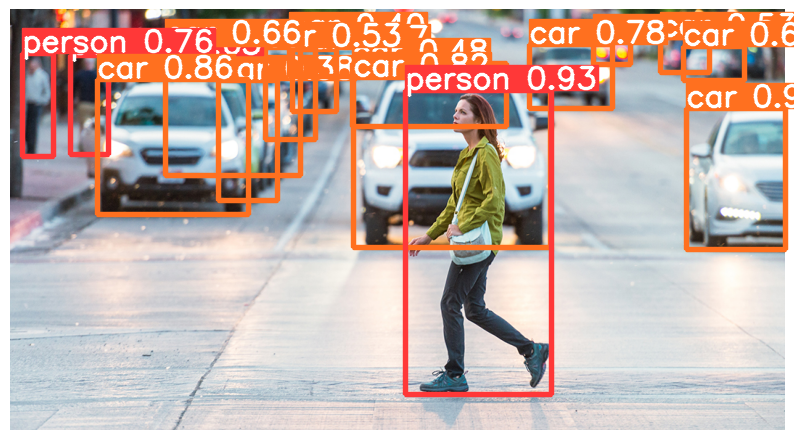

In [ ]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/runs/detect/exp3/test_yolo.png", width=600)

## Download the Dataset

In [ ]:
%cd {HOME}/yolov9

/content/yolov9


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="PREtYuS13VXPKlpKYGKD")
project = rf.workspace("capstone-cra8x").project("citypersons-woqjq-ike0o-dtqfy")
version = project.version(1)
dataset = version.download("yolov9")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Citypersons-1 in yolov9:: 100%|██████████| 6962/6962 [00:02<00:00, 3213.52it/s]


In [ ]:
print(dataset.location)

/content/yolov9/Citypersons-1


## Train Custom Model

change weights_only= False in train.py too (torch.load function)

Line 108 and 496

NOTE: check folder path config in data.yaml file

In [ ]:
%cd {HOME}/yolov9

!python train.py \
--batch 16 --epochs 100 --img 640 --device 0 --min-items 0 \
--data {dataset.location}/data.yaml \
--weights {HOME}/weights/gelan-s.pt \
--cfg models/detect/gelan-s.yaml \
--hyp hyp.scratch-high.yaml \
--patience 10

/content/yolov9
2025-09-15 10:46:14.583889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757933174.602786    9523 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757933174.608589    9523 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757933174.623496    9523 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757933174.623521    9523 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1757933174.623525    9523 computation_placer.cc:177] comput

10 epochs completed in 0.452 hours.
Traceback (most recent call last):
  File "/content/yolov9/train.py", line 634, in <module>
    main(opt)
  File "/content/yolov9/train.py", line 528, in main
    train(opt.hyp, opt, device, callbacks)
  File "/content/yolov9/train.py", line 403, in train
    strip_optimizer(f, last_striped)  # strip optimizers
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/yolov9/utils/general.py", line 999, in strip_optimizer
    x = torch.load(f, map_location=torch.device('cpu'))
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/serialization.py", line 1470, in load
    raise pickle.UnpicklingError(_get_wo_message(str(e))) from None
_pickle.UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint.
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([_reconstruct])` or the `torch.serialization.safe_globals([_reconstruct])` context manager to allowlist this global if you trust this class/function.



## Validate Custom Model

In [ ]:
%cd {HOME}/yolov9

!python val.py \
--img 640  --device 0 \
--data {dataset.location}/data.yaml \
--weights {HOME}/yolov9/runs/train/exp4/weights/best.pt

/content/yolov9
val: data=/content/yolov9/Citypersons-1/data.yaml, weights=['/content/yolov9/runs/train/exp4/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
gelan-s summary: 489 layers, 7076089 parameters, 0 gradients, 26.2 GFLOPs
val: Scanning /content/yolov9/Citypersons-1/valid/labels.cache... 342 images, 13 backgrounds, 0 corrupt: 100% 342/342 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:   9% 1/11 [00:02<00:23,  2.35s/it]Exception in thread Thread-3 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in

## Inference with Custom Model

In [ ]:
!python detect.py \
--img 640 --device 0 \
--weights {HOME}/yolov9/runs/train/exp4/weights/best.pt \
--source {dataset.location}/test/images

detect: weights=['/content/yolov9/runs/train/exp4/weights/best.pt'], source=/content/yolov9/Citypersons-1/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
gelan-s summary: 489 layers, 7076089 parameters, 0 gradients, 26.2 GFLOPs
image 1/341 /content/yolov9/Citypersons-1/test/images/aachen_000002_000019_leftImg8bit_png.rf.fb4b114d0b573cf6bb0a85130fb6a52c.jpg: 320x640 3 peds, 61.9ms
image 2/341 /content/yolov9/Citypersons-1/test/images/aachen_000003_000019_leftImg8bit_png.rf.b7e8f36ea4590701f8e2c62981c36bd3.jpg: 320x640 (no detecti

In [ ]:
!python detect.py --weights {HOME}/yolov9/runs/train/exp4/weights/best.pt --source "/content/test_yolo.png" --device 0

detect: weights=['/content/yolov9/runs/train/exp4/weights/best.pt'], source=/content/test_yolo.png, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
gelan-s summary: 489 layers, 7076089 parameters, 0 gradients, 26.2 GFLOPs
image 1/1 /content/test_yolo.png: 384x640 4 peds, 86.1ms
Speed: 0.5ms pre-process, 86.1ms inference, 97.8ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp5


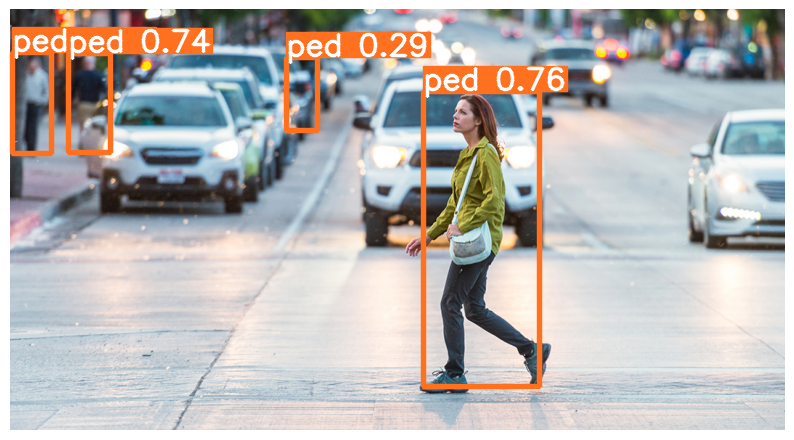

In [ ]:
Image(filename=f"{HOME}/yolov9/runs/detect/exp5/test_yolo.png", width=600)

In [ ]:
#path that contains folder you want to copy
%cd /content/drive/MyDrive/MLPR_new_runs/yolov9_MLPR
%cp -av /content/yolov9/runs /content/drive/MyDrive/MLPR_new_runs/yolov9

/content/drive/MyDrive/MLPR_new_runs/yolov9_MLPR
'/content/yolov9/runs' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs'
'/content/yolov9/runs/detect' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs/detect'
'/content/yolov9/runs/detect/exp' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs/detect/exp'
'/content/yolov9/runs/detect/exp/test_yolo.png' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs/detect/exp/test_yolo.png'
'/content/yolov9/runs/detect/exp2' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs/detect/exp2'
'/content/yolov9/runs/detect/exp3' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs/detect/exp3'
'/content/yolov9/runs/detect/exp3/test_yolo.png' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs/detect/exp3/test_yolo.png'
'/content/yolov9/runs/detect/exp4' -> '/content/drive/MyDrive/MLPR_new_runs/yolov9/runs/detect/exp4'
'/content/yolov9/runs/detect/exp4/aachen_000002_000019_leftImg8bit_png.rf.fb4b114d0b573cf6bb0a85130fb6a52c.jpg' -> '/content/

In [ ]:
!grep -rnw '/content/yolov9' -e 'torch.load'

/content/yolov9/train.py:108:        ckpt = torch.load(weights, map_location='cpu', weights_only=False)  # load checkpoint to CPU to avoid CUDA memory leak
/content/yolov9/train.py:496:            d = torch.load(last, map_location='cpu')['opt']
/content/yolov9/tools/reparameterization.ipynb:35:    "ckpt = torch.load('./yolov9-s.pt', map_location='cpu')\n",
/content/yolov9/tools/reparameterization.ipynb:138:    "ckpt = torch.load('./yolov9-m.pt', map_location='cpu')\n",
/content/yolov9/tools/reparameterization.ipynb:241:    "ckpt = torch.load('./yolov9-c.pt', map_location='cpu')\n",
/content/yolov9/tools/reparameterization.ipynb:336:    "ckpt = torch.load('./yolov9-e.pt', map_location='cpu')\n",
/content/yolov9/utils/loggers/__init__.py:104:            run_id = torch.load(self.weights).get('wandb_id') if self.opt.resume and not wandb_artifact_resume else None
/content/yolov9/utils/general.py:999:    x = torch.load(f, map_location=torch.device('cpu'))
/content/yolov9/train_dual.py:110:  

#References

1. Model: https://github.com/WongKinYiu/yolov9
2. Dataset: https://universe.roboflow.com/citypersons-conversion/citypersons-woqjq